# P2PCommunicator
- 这是流水线并行（Pipeline Parallelism）中的核心通信组件。
- https://github.com/NVIDIA/Megatron-LM/blob/main/megatron/core/pipeline_parallel/p2p_communication.py#L140

In [1]:
from IPython.display import Image

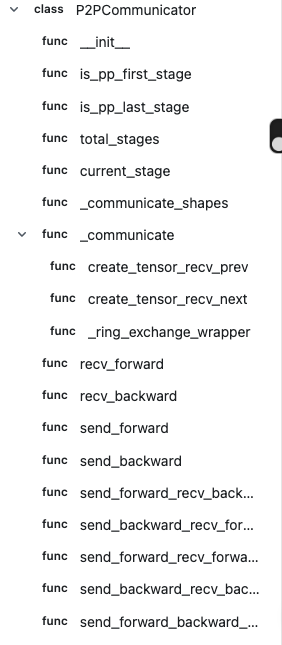

In [2]:
Image(filename='./P2PCommunicator.png')

In [ ]:
┌─────────────────────────────────────────────────────────────┐
│                    流水线并行架构 (PP)                        │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│   GPU 0          GPU 1          GPU 2          GPU 3        │
│  ┌─────┐       ┌─────┐       ┌─────┐       ┌─────┐       │
│  │Stage│──────→│Stage│──────→│Stage│──────→│Stage│       │
│  │  0  │       │  1  │       │  2  │       │  3  │       │
│  │(Rank│       │(Rank│       │(Rank│       │(Rank│       │
│  │  0) │←──────│  1) │←──────│  2) │←──────│  3) │       │
│  └─────┘       └─────┘       └─────┘       └─────┘       │
│     ↑             ↑             ↑             ↑           │
│   前向发送      前向发送      前向发送      前向发送(回绕)   │
│   反向接收      反向接收      反向接收      反向接收(回绕)   │
│                                                             │
│   前向: send_next → receive_prev (activation 传递)          │
│   反向: send_prev → receive_next (gradient 传递)            │
│                                                             │
└─────────────────────────────────────────────────────────────┘

| 要点       | 说明                                          |
| -------- | ------------------------------------------- |
| **P2P**  | Point-to-Point，点对点通信，即一对一发送/接收              |
| **作用**   | 管理流水线中相邻阶段（stage）之间的张量交换                    |
| **通信内容** | 前向传播时的 **activations**，反向传播时的 **gradients** |


| 参数         | 类型                    | 含义                                      |
| ---------- | --------------------- | --------------------------------------- |
| `pp_group` | `dist.ProcessGroup`   | PyTorch 分布式中的**流水线并行进程组**，包含所有参与 PP 的进程 |
| `config`   | `ModelParallelConfig` | 模型并行配置，包含并行策略的各种超参数                     |

## 关键概念：局部 Rank vs 全局 Rank

| 概念          | 含义                         | 类比      |
| ----------- | -------------------------- | ------- |
| **全局 Rank** | 在整个分布式训练集群中的唯一编号           | 全校学生的学号 |
| **局部 Rank** | 在某个特定进程组（ProcessGroup）内的编号 | 班级内的序号  |

## 场景设定

假设有 8 张 GPU，采用以下并行策略：
- 张量并行（TP）：2 张 GPU 一组，共 4 组
- 流水线并行（PP）：4 个 stage，每个 stage 由 1 个 TP 组承担

In [ ]:
┌─────────────────────────────────────────────────────────────┐
│                    8 张 GPU 布局                              │
├─────────────────────────────────────────────────────────────┤
│                                                             │
│   全局 Rank:    0      1      2      3      4      5      6      7
│                │      │      │      │      │      │      │      │
│   GPU:        GPU0   GPU1   GPU2   GPU3   GPU4   GPU5   GPU6   GPU7
│                │      │      │      │      │      │      │      │
│   TP 组:      ├──TP0─┤      ├──TP1─┤      ├──TP2─┤      ├──TP3─┤
│                │             │             │             │
│   PP Stage:   Stage 0       Stage 1       Stage 2       Stage 3
│                                                             │
└─────────────────────────────────────────────────────────────┘

In [ ]:
import torch.distributed as dist

# ========== 1. 全局视角：world group ==========
# 包含所有 8 个进程
world_group = dist.new_group(ranks=[0, 1, 2, 3, 4, 5, 6, 7])

# 每个进程的全局 rank（在整个集群中唯一）
global_rank = dist.get_rank()  # 范围: 0 ~ 7


# ========== 2. 张量并行组（TP Group）==========
# TP0: 负责 Stage 0 的张量并行
tp_group_0 = dist.new_group(ranks=[0, 1])

# TP1: 负责 Stage 1 的张量并行  
tp_group_1 = dist.new_group(ranks=[2, 3])

# TP2: 负责 Stage 2 的张量并行
tp_group_2 = dist.new_group(ranks=[4, 5])

# TP3: 负责 Stage 3 的张量并行
tp_group_3 = dist.new_group(ranks=[6, 7])


# ========== 3. 流水线并行组（PP Group）==========
# 每个 TP 组选出一个代表参与 PP
# 这里选每个 TP 组的 rank 0（即全局 rank 0, 2, 4, 6）
pp_group = dist.new_group(ranks=[0, 2, 4, 6])

### 以 全局 Rank 4 为例：

In [ ]:
# 当前进程的全局 rank
global_rank = 4

# 获取所在的各种进程组
tp_group = tp_group_2    # ranks=[4, 5]
pp_group = pp_group      # ranks=[0, 2, 4, 6]

# ========== 局部 Rank ==========
tp_local_rank = dist.get_rank(tp_group)   # 在 TP 组内的序号 → 0（只有0和1）
pp_local_rank = dist.get_rank(pp_group)   # 在 PP 组内的序号 → 2

print(f"全局 Rank {global_rank}:")
print(f"  - 在 TP 组中: 局部 rank = {tp_local_rank}")  # 0
print(f"  - 在 PP 组中: 局部 rank = {pp_local_rank}")  # 2


# ========== P2PCommunicator 中的关键转换 ==========
world_size = pp_group.size()           # 4 (PP 组有 4 个进程)
curr_rank_in_pg = pp_group.rank()      # 2 (当前在 PP 组中的局部 rank)

# 计算下一个/上一个阶段的局部 rank
next_rank_pg = (2 + 1) % 4   # → 3
prev_rank_pg = (2 - 1) % 4   # → 1

# 转换为全局 rank（用于实际通信）
next_rank_global = dist.get_global_rank(pp_group, 3)  # → 全局 Rank 6
prev_rank_global = dist.get_global_rank(pp_group, 1)  # → 全局 Rank 2

print(f"  - 前向发送目标 (next): 局部={next_rank_pg}, 全局={next_rank_global}")  # 3 → 6
print(f"  - 反向发送目标 (prev): 局部={prev_rank_pg}, 全局={prev_rank_global}")  # 1 → 2

In [ ]:
class P2PCommunicator:
    """P2P (Point-to-Point) Communicator for pipeline parallelism.

    This class handles communication between pipeline stages by managing
    tensor exchanges between consecutive stages in the pipeline.
    """

    def __init__(self, pp_group: dist.ProcessGroup, config: ModelParallelConfig):
        # Basic attrs
        self.pp_group = pp_group
        self.config = config

        world_size = self.pp_group.size()      # 流水线并行组中的进程总数
        curr_rank_in_pg = self.pp_group.rank() # 当前进程在组内的局部 rank

        next_rank_pg = (curr_rank_in_pg + 1) % world_size # 下一个阶段（前向发送目标）
        prev_rank_pg = (curr_rank_in_pg - 1) % world_size # 上一个阶段（反向发送目标）

        '''
        转换为全局 Rank:将进程组内的局部 rank 转换为全局 rank
        
        为什么需要全局 Rank？
        PyTorch 分布式通信（如 dist.send()/dist.recv()）需要使用全局 rank 来标识目标进程。
        '''
        self.next_rank: int | None = dist.get_global_rank(self.pp_group, next_rank_pg)
        self.prev_rank: int | None = dist.get_global_rank(self.pp_group, prev_rank_pg)
        '''
        virtual_pipeline_model_parallel_size	虚拟流水线切分的份数
        '''
        self.virtual_pipeline_model_parallel_size = (
            config.virtual_pipeline_model_parallel_size
            if config.virtual_pipeline_model_parallel_size is not None
            else None
        )


# _communicate
- <font color='red'>这是 Megatron 中流水线并行点对点通信的核心实现。</font>
- 这个方法是 Megatron 流水线并行的通信基石，所有高级的流水线调度策略（1F1B、Interleaved、Zero-Bubble 等）最终都通过它来完成实际的数据传输。


| 英文                        | 中文            | 说明                              |
| ------------------------- | ------------- | ------------------------------- |
| `tensor_send_next`        | 发送给下一阶段的张量    | `next` = 流水线中靠后的 stage          |
| `tensor_send_prev`        | 发送给上一阶段的张量    | `prev` = 流水线中靠前的 stage          |
| `recv_prev` / `recv_next` | 接收标志          | 控制是否执行接收操作                      |
| `wait_on_reqs`            | 等待请求          | `True` 时阻塞等待通信完成；`False` 时异步返回  |
| `megatron/schedules.py`   | Megatron 调度模块 | 定义流水线调度策略（如 1F1B、Interleaved 等） |

## 整体流程图

In [ ]:
┌─────────────────────────────────────────────────────────────────┐
│                    _communicate 执行流程                          │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  1. 确定接收张量形状                                              │
│     ├── 变长序列 / MTP 独立模式: 先通信形状                        │
│     └── 固定长度: 直接使用 tensor_shape                           │
│                                                                 │
│  2. 创建接收张量的工厂函数                                         │
│     ├── create_tensor_recv_prev() → 空张量 (prev方向)             │
│     └── create_tensor_recv_next() → 空张量 (next方向)             │
│                                                                 │
│  3. 校验配置（dtype、shape 必须提供）                              │
│                                                                 │
│  4. 选择 P2P 通信后端                                             │
│     ├── ring_exchange (环形交换)                                  │
│     ├── batched_p2p (批量通信)                                    │
│     └── p2p_ops (标准点对点)                                      │
│                                                                 │
│  5. 创建接收缓冲区并执行通信                                       │
│                                                                 │
│  6. 等待请求完成（若 wait_on_reqs=True）                          │
│                                                                 │
│  7. 同步 CUDA（防止竞态条件）                                      │
│                                                                 │
│  8. 返回接收到的张量                                              │
│                                                                 │
└─────────────────────────────────────────────────────────────────┘

In [ ]:
"""在流水线各阶段之间通信张量。用作 megatron/schedules.py 中其他通信方法的辅助方法。

参数:
    tensor_send_next (torch.Tensor, 可选):
        要发送给下一个 rank 的张量（若为 None 则不发送张量）

    tensor_send_prev (torch.Tensor, 可选):
        要发送给上一个 rank 的张量（若为 None 则不发送张量）

    recv_prev (布尔值, 必需):
        是否应从上一个 rank 接收张量。

    recv_next (布尔值, 必需):
        是否应从下一个 rank 接收张量。

    tensor_shape (List[int] 或 torch.Size, 必需):
        要接收的张量的形状（此方法假设单次函数调用中发送和接收的所有张量形状相同）。

    wait_on_reqs (布尔值, 可选, 默认 False):
        对于非批量的点对点通信，在返回前等待每个请求完成。

返回:
    包含以下内容的元组

    - tensor_recv_prev: 若 recv_prev 为 True 则为 torch.Tensor，否则为 None。
    - tensor_recv_next: 若 recv_next 为 True 则为 torch.Tensor，否则为 None。
"""

In [ ]:
   def _communicate(
        self,
        *,
        tensor_send_next: Optional[torch.Tensor],
        tensor_send_prev: Optional[torch.Tensor],
        recv_prev: bool,
        recv_next: bool,
        tensor_shape: Shape,
        wait_on_reqs: bool = True,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
       
        '''
        确定接收张量的形状
        
        固定长度 (else)	直接用 tensor_shape	所有 micro-batch 序列长度相同，形状已知
        
        变长序列	先 _communicate_shapes	不同 micro-batch 可能有不同序列长度，需要动态协商形状
        MTP 独立	先 _communicate_shapes	Multi-Token Prediction 独立模式需要特殊处理

        '''
        config = self.config
        tensor_recv_prev_func = None
        tensor_recv_next_func = None

        if config.variable_seq_lengths or config.mtp_standalone:
            # 变长序列 或 MTP 独立模式：需要先通信形状
            recv_prev_shape, recv_next_shape = self._communicate_shapes(
                tensor_send_next, tensor_send_prev, recv_prev, recv_next
            )
        else:
            # 固定长度：直接使用传入的形状
            recv_prev_shape = tensor_shape
            recv_next_shape = tensor_shape

        '''
        创建接收张量的工厂函数
        
        为什么用工厂函数而不是直接创建？
          惰性创建：只在需要接收时才创建，避免不必要的内存分配
          封装逻辑：创建逻辑集中，便于维护
        '''
        def create_tensor_recv_prev():
            return torch.empty(
                recv_prev_shape,                   # 接收形状
                requires_grad=True,                # 需要梯度（用于反向传播）
                device=torch.cuda.current_device(),# 当前 GPU
                dtype=config.pipeline_dtype,       # 流水线数据类型（如 fp16/bf16）
            )

        def create_tensor_recv_next():
            return torch.empty(
                recv_next_shape,
                requires_grad=True,
                device=torch.cuda.current_device(),
                dtype=config.pipeline_dtype,
            )

        '''
        配置校验
        
        pipeline_dtype	必须指定数据类型（fp32/fp16/bf16）
        tensor_shape	必须指定形状，并给出常见格式示例
        
        (seq_length, micro_batch_size, hidden_size)

        示例: (2048, 4, 4096)
              ↑      ↑    ↑
              |      |    └── 隐藏层维度 (如 LLaMA-7B 的 4096)
              |      └─────── micro-batch 大小
              └────────────── 序列长度
        '''
        if recv_prev:
            if config.pipeline_dtype is None:
                raise RuntimeError("pipeline_dtype must be provided if recv_prev is True")
            if tensor_shape is None:
                raise RuntimeError(
                    "tensor_shape must be specified if recv_prev is True. "
                    "Common tensor_shape is (seq_length, micro_batch_size, hidden_size)"
                )
            tensor_recv_prev_func = create_tensor_recv_prev

        if recv_next:
            if config.pipeline_dtype is None:
                raise RuntimeError("dtype must be provided if recv_next is True")
            if tensor_shape is None:
                raise RuntimeError(
                    "tensor_shape must be specified if recv_next is True. "
                    "Common tensor_shape is (seq_length, micro_batch_size, hidden_size)"
                )
            tensor_recv_next_func = create_tensor_recv_next

        '''
        选择 P2P 通信后端
        
        ring_exchange	NVLink 全连接拓扑	利用硬件拓扑环形传输，避免拥塞
        batch_p2p_comm	大量小通信	合并 isend/irecv 为 batch_isend_irecv，减少 CPU 开销
        p2p_ops	通用场景	标准 isend/irecv，最灵活
        
        
        '''
        # Send tensors in both the forward and backward directions as appropriate.
        if config.use_ring_exchange_p2p:

            def _ring_exchange_wrapper(**kwargs):
                torch.distributed.ring_exchange(**kwargs)
                return []

            p2p_func = _ring_exchange_wrapper
        elif config.batch_p2p_comm:
            # 批量通信：合并多个通信操作，减少启动开销
            assert wait_on_reqs # 批量模式必须等待
            p2p_func = _batched_p2p_ops
        else:
            # 标准点对点：逐个发送/接收
            p2p_func = _p2p_ops

        '''
        初始化请求容器
        '''
        pp_group = self.pp_group
        next_rank = self.next_rank
        prev_rank = self.prev_rank

        if config.use_ring_exchange_p2p or config.batch_p2p_comm:
            reqs = [] # list: 批量/环形模式用列表
        else:
            reqs = {} # dict: 标准模式用字典，可按 key 查找

        '''
        创建接收缓冲区并执行通信
        '''
        tensor_recv_prev = None
        tensor_recv_next = None
        
        # 惰性创建接收张量
        if tensor_recv_prev_func is not None:
            tensor_recv_prev = tensor_recv_prev_func()

        if tensor_recv_next_func is not None:
            tensor_recv_next = tensor_recv_next_func()

        '''
        通信模式矩阵：
        
                            recv_prev=True          recv_prev=False
                          ┌─────────────────┬─────────────────┐
            send_next=有   │  前向+反向混合   │   只发前向       │
                          │  (中间 stage)   │  (第一个 stage) │
                          ├─────────────────┼─────────────────┤
            send_next=无   │   只收反向       │    无通信        │
                          │  (最后一个 stage)│   (不可能出现)   │
                          └─────────────────┴─────────────────┘
        '''
        
        p2p_reqs = p2p_func(
            tensor_send_prev=tensor_send_prev,# 发送给 prev 的张量
            tensor_recv_prev=tensor_recv_prev,# 从 prev 接收的缓冲区
            
            tensor_send_next=tensor_send_next,# 发送给 next 的张量
            tensor_recv_next=tensor_recv_next,# 从 next 接收的缓冲区
            group=pp_group,                   # 进程组
            prev_pipeline_rank=prev_rank, # 上一个 stage 的全局 rank
            next_pipeline_rank=next_rank, # 下一个 stage 的全局 rank
        )
        
        '''
        合并请求并等待
        '''
        if isinstance(p2p_reqs, list):
            reqs.extend(p2p_reqs)
        else:
            reqs.update(p2p_reqs)

        '''
        # 阻塞等待所有通信完成
        
        
        wait_on_reqs	行为	使用场景
        True	阻塞等待	需要立即使用数据的场景
        False	异步返回	计算与通信重叠（overlap），隐藏通信延迟

        '''
        if wait_on_reqs and len(reqs) > 0:
            for req in reqs if isinstance(reqs, list) else reqs.values():
                req.wait()
            reqs = None

        '''
        CUDA 同步（防止竞态条件）
        
        '''
        if config.batch_p2p_comm and config.batch_p2p_sync:
            # To protect against race condition when using batch_isend_irecv().
            # User should assert that we have a modern enough PyTorch to not need this
            
            # 使用 batch_isend_irecv() 时的竞态条件保护
            # 用户应确保 PyTorch 版本足够新，不需要此项
            torch.cuda.synchronize()

        return tensor_recv_prev, tensor_recv_next, reqs


## 完整通信场景示例
### 场景 1：中间 Stage（前向传播）

In [ ]:
Stage 1 (中间阶段):
    tensor_send_next = activation_from_forward   # 发给 Stage 2
    tensor_send_prev = None                       # 不反向发
    recv_prev = True                              # 从 Stage 0 收
    recv_next = False                             # 前向时不从后收
    
    → 接收: activation from Stage 0 (用于本 stage 计算)
    → 发送: activation to Stage 2

### 场景 2：中间 Stage（反向传播）

In [ ]:
Stage 1 (中间阶段):
    tensor_send_next = None                       # 反向不向 next 发
    tensor_send_prev = gradient_from_backward     # 梯度发给 Stage 0
    recv_prev = False                             # 反向不从 prev 收
    recv_next = True                              # 从 Stage 2 收梯度
    
    → 接收: gradient from Stage 2 (用于本 stage 反向)
    → 发送: gradient to Stage 0

### 场景 3：1F1B（One-Forward-One-Backward）调度

In [ ]:
时间线:
    T1: F0 (Stage 0) → F0 (Stage 1) → F0 (Stage 2)
    T2: F1 (Stage 0) → B0 (Stage 2) → B0 (Stage 1)
    T3: F2 (Stage 0) → F1 (Stage 1) → B0 (Stage 0)
    T4: B1 (Stage 2) → F2 (Stage 1) → B1 (Stage 0)
    
每个步骤都调用 _communicate 进行张量交换